## About

This project performs a regression analysis on the "Vinho Verde" wine quality dataset. The goal is to understand which physicochemical properties (like acidity, sugar, alcohol, etc.) influence the sensory quality ratings of red wine.

The analysis includes:
- **Exploratory Data Analysis (EDA):** Correlation analysis and data cleaning.
- **Hypothesis Testing:** Investigating relationships between chemical properties and quality.
- **Linear Regression Modeling:** Predicting wine quality based on physicochemical features.
- **Model Evaluation:** Interpreting coefficients and checking statistical significance.

**Dataset:**
- [Red Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality) (Cortez et al., 2009).

**Context:**

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult the reference [Cortez et al., 2009]. Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

**Goal:**

We want to explore the relationship between the features - physicochemical and the output - the perceived quality.
We train a simple regression model and try to fit the model to our data, and sample from it.

## Load the dataset and Overview of the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import shutil

In [2]:
from consts import WINE_QUALITY_DATASET
from utils import plot_regression

We use a copy of our dataset to leave the original one untouched.

In [3]:
shutil.copy(WINE_QUALITY_DATASET, "Datasets/winequality-red-copy.csv")
wine_data = pd.read_csv("Datasets/winequality-red-copy.csv")

In [4]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


We see that the dataset consists of 1599 entries and 12 columns. All independent variables are numeric (float64), and the target variable 'quality' is an integer.

## Data Cleaning

Checking for missing values.

In [6]:
wine_data.isna().mean() * 100

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

We see that no values are missing.

Now let's check for duplicate rows and columns:

In [7]:
print(wine_data.duplicated().any())

wine_data_t = wine_data.T
print(wine_data_t.duplicated().any())

True
False


In [8]:
print(f"Number of duplicate rows: {wine_data.duplicated().sum()}")

Number of duplicate rows: 240


We identified duplicate rows in the dataset. 

While it is physically possible for different wines to have identical chemical properties and quality (same wine ranked twice or simply a duplicate, but we aren't sure), cause the perceived quality duplicate entries can potentially bias the model evaluation if they appear in both training and test sets. The problem would be that our model could "memorize" rather than "learn" the relationship and linear regression as applied later assumes independent observations. 

In [31]:
print((wine_data.groupby(wine_data.columns.drop('quality').tolist())['quality'].nunique() > 1).sum().item())
wine_data = wine_data.drop_duplicates().reset_index(drop=True)

0


All chemically identical duplicates exhibit the same perceived quality score. - this speaks for simply duplicates.

Therefore we drop them to be save.

## Key Information about the Dataset

We start with the sample size - the number of reviews on red/white variants of the "Vinho Verde" wine.

In [10]:
print(f"sample size: {len(wine_data)}")

sample size: 1359


Now we take a look at how the quality is distributed here.

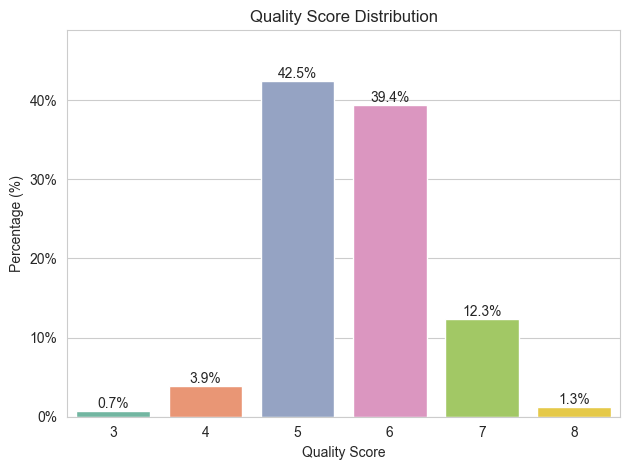

In [11]:
quality_proportions = wine_data["quality"].value_counts(normalize=True).sort_index()

sns.set_style("whitegrid")
colors = sns.color_palette("Set2", n_colors=len(quality_proportions))
ax = sns.barplot(
    x=quality_proportions.index,
    y=quality_proportions.values,
    legend=False,
    hue=quality_proportions.index,
    palette=colors,
)
for container in ax.containers:
    ax.bar_label(
        container, labels=[f"{v*100:.1f}%" for v in container.datavalues], fontsize=10
    )
plt.title("Quality Score Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Quality Score")
plt.ylim(0, max(quality_proportions.values) * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
plt.tight_layout()
plt.show()

We have a min perceived quality of 3 and a max of 8, with the majority of the wines being perceived in quality range 5-6 (5: ~43%, 6: ~40%), followed by 7, 4 and ending with the extremes - 3 and 8. All on scale 0-10.

#### Key Information about the Dataset - Summary:

The data was collected 2009 in the north of Portugal, for more context see the About section at the top.

**Sample Size:**

number of reviews on red/white variants of the "Vinho Verde" wine: 1359


**Input Variables:**
1. fixed acidity - most acids involved with wine or fixed or nonvolatile (do not evaporate readily)
2. volatile acidity - the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
3. citric acid - found in small quantities, citric acid can add 'freshness' and flavor to wines
4. residual sugar - the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and
5. chlorides - the amount of salt in the wine
6. free sulfur dioxide - the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents
7. total sulfur dioxide - amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2
8. density - the density of water is close to that of water depending on the percent alcohol and sugar content
9. pH - describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4
10. sulphates - a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial
11. alcohol - percentage


**Output Variable:**

quality - (based on sensory data, score between 0 and 10)

min perceived quality of 3 and a max of 8, with the majority of the wines being perceived in quality range 5-6 (5: ~43%, 6: ~40%), followed by 7, 4 and ending with the extremes - 3 and 8.

## Hypothesis Formulation

**Alternative Hypothesis:** 

1. High pH-value has a NEGATIVE impact on perceived wine quality.

2. Fixed acidity of wine has a NEGATIVE impact on perceived wine quality.

3. Higher alcohol content has a POSITIVE impact on perceived wine quality.

**Nullhypothesis:**

1. The pH-value has NO impact on perceived wine quality.

2. Fixed acidity of wine has NO impact on perceived wine quality.

3. Alcohol content has NO impact on perceived wine quality.


**Significance Level:** 0.05

## EDA 

Perform EDA. Inspect variables separately, plot how they correlate with the independent variable and one another. Check for multicollinearity.

We start with general **correlations** of every input variable (independent) to the output variable (dependent)

In [12]:
wine_corr_q = wine_data.corr()["quality"]
wine_corr_q

fixed acidity           0.119024
volatile acidity       -0.395214
citric acid             0.228057
residual sugar          0.013640
chlorides              -0.130988
free sulfur dioxide    -0.050463
total sulfur dioxide   -0.177855
density                -0.184252
pH                     -0.055245
sulphates               0.248835
alcohol                 0.480343
quality                 1.000000
Name: quality, dtype: float64

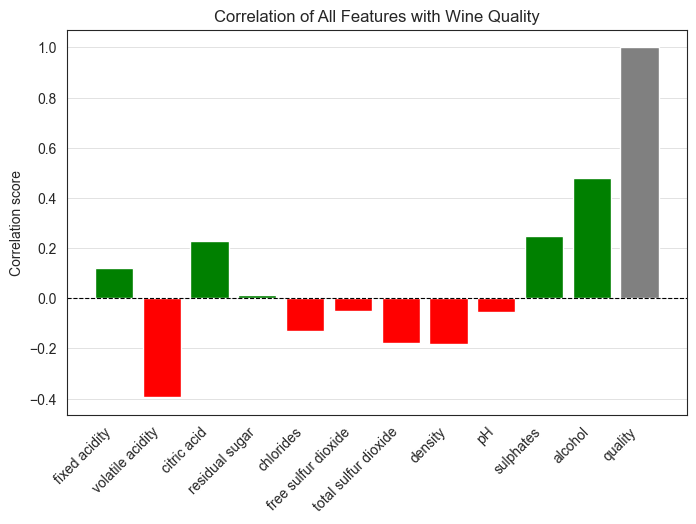

In [13]:
sns.set_style("white")
x = range(len(wine_corr_q))

plt.figure(figsize=(8, 5))
colors = [
    "grey" if var == "quality" else ("green" if val > 0 else "red")
    for var, val in wine_corr_q.items()
]
plt.bar(
    x,
    wine_corr_q,
    capsize=5,
    color=colors,
)
plt.xticks(x, wine_corr_q.index, rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel("Correlation score")
plt.title("Correlation of All Features with Wine Quality")
plt.grid(axis="y", alpha=0.8, linestyle="-", linewidth=0.5)
plt.gca().set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
plt.show()

We observe that there are no strong correlations (|r| > 0.7) between the independent variables and perceived wine quality. However, several moderate to weak correlations emerge:

Positive Correlations:

- Alcohol shows a moderate positive correlation (r ≈ 0.48), indicating that wines with higher alcohol content tend to receive higher quality ratings.
- Citric acid and sulphates exhibit weak positive correlations (r ≈ 0.2), suggesting a slight tendency toward improved quality with higher concentrations.

Negligible Correlations:

- Fixed acidity and residual sugar show virtually no relationship with quality (|r| < 0.12), indicating these variables have minimal influence on perceived quality ratings.
- Chlorides, pH and free sulfur dioxide similarly show negligible correlations.

Negative Correlations:

- Volatile acidity demonstrates a moderate negative correlation (r ≈ -0.4), meaning higher acetic acid levels are associated with lower quality ratings
- Total sulfur dioxide and density show weak negative correlations with perceived quality.

Later we will check whether those tendencies are **statistically significant**.

Now we check for **Multicollinearity**, meaning two or more independent variables are highly correlated with each other. We do this to prevent our model from producing unreliable and unstable coefficient estimates for inputs that essentially measure the same underlying phenomenon.

First we get a general overview via the correlation matrix.

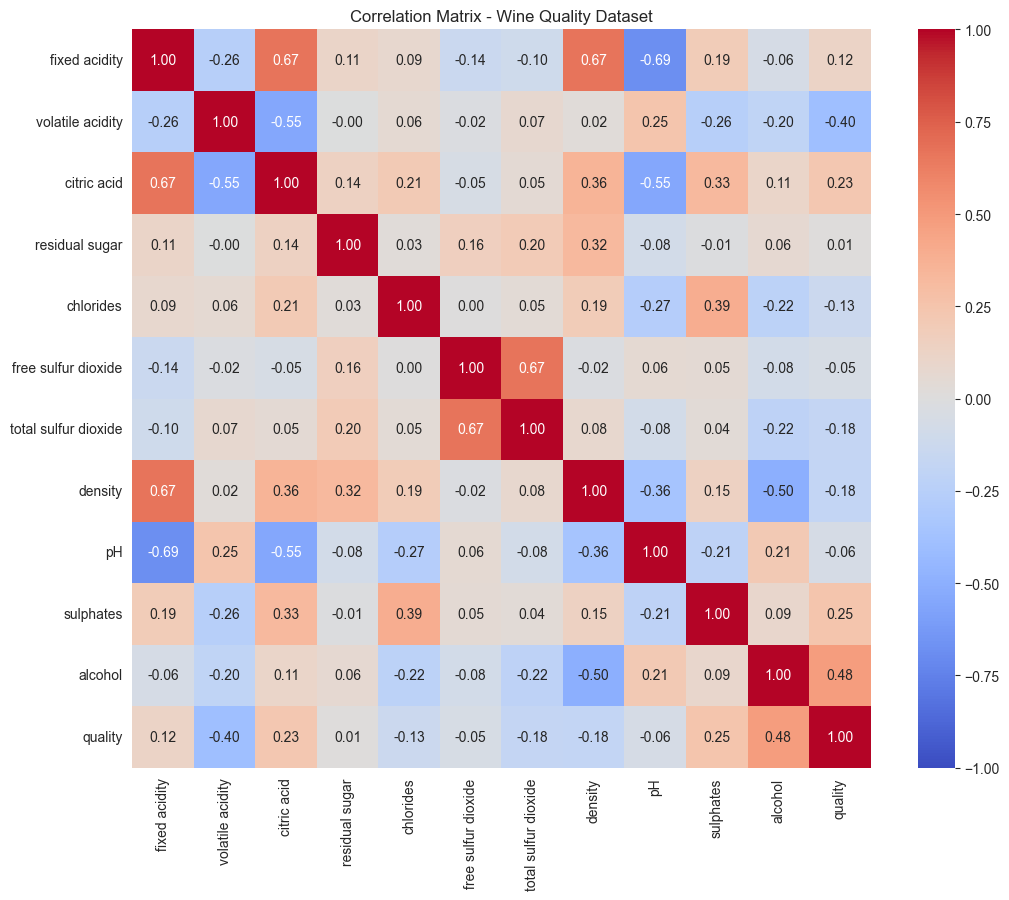

In [14]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    wine_data.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix - Wine Quality Dataset")
plt.tight_layout()
plt.show()

Now we observe the VIF (Variance Inflation Factor) to specifically check for multicollinearity.

In [15]:
X_ = wine_data.drop(["quality"], axis=1)
X = sm.add_constant(X_)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)

In [16]:
vif_data[1:]

,Variable,VIF
1,fixed acidity,7.88
8,density,6.28
9,pH,3.40
11,alcohol,3.14
3,citric acid,3.12
7,total sulfur dioxide,2.22
6,free sulfur dioxide,1.95
2,volatile acidity,1.78
4,residual sugar,1.64
5,chlorides,1.53


We observe high VIF values (>6) for several variables, particularly Fixed acidity and density.

This indicates strong multicollinearity, meaning these features are highly correlated with some other features (e.g., density is chemically related to sugar and alcohol content). 

We therefore remove features with high VIF to improve stability for our refined model.

In [17]:
X_ = wine_data.drop(["quality", "fixed acidity", "density"], axis=1)
X = sm.add_constant(X_)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)

In [18]:
vif_data[1:]

,Variable,VIF
2,citric acid,2.20
6,total sulfur dioxide,2.03
5,free sulfur dioxide,1.93
1,volatile acidity,1.64
7,pH,1.64
4,chlorides,1.40
8,sulphates,1.37
9,alcohol,1.30
3,residual sugar,1.09


Now multicollinearity should be fine.

## Seperate test data and Selecting variables, transformations

Now we construct the model.

We start with separating a random 20% of your dataset as a hold-out. 
Afterwards we select variables and their transformations for our model as needed.

We start by splitting our data into training and test data.

In [19]:
n = int(0.8 * len(wine_data))
train_data = wine_data[:n]
test_data = wine_data[n:]

Now we are going to select all the necessary variables and possibly apply transformations.

First we are using all features without transformations.

In [20]:
x_train_org = train_data.drop("quality", axis=1)
y_train_org = train_data["quality"].copy()

x_test_org = test_data.drop("quality", axis=1)
y_test_org = test_data["quality"].copy()

X_train_org_sm = sm.add_constant(x_train_org)
X_test_org_sm = sm.add_constant(x_test_org)

Now we transform our relevant features, we scale them using Standardization (Z-Score Normalization). We do that to ensure a fair comparison of influence across all features, converting every continuous feature to a new scale where they aren't distorted by the original units.

In [21]:
rel_features = [
    "volatile acidity",
    "alcohol",
    "sulphates",
    "citric acid",
    "free sulfur dioxide",
    "pH",
    "residual sugar",
    "chlorides",
    "total sulfur dioxide",
]

In [22]:
x_train_ = train_data[rel_features]
y_train = train_data["quality"].copy()

x_test_ = test_data[rel_features]
y_test = test_data["quality"].copy()

scaler = StandardScaler()
x_train = pd.DataFrame(
    scaler.fit_transform(x_train_), columns=rel_features, index=x_train_.index
)

x_test = pd.DataFrame(
    scaler.transform(x_test_), columns=rel_features, index=x_test_.index
)

X_train_sm = sm.add_constant(x_train)
X_test_sm = sm.add_constant(x_test)

## Fitting the model

Now we fit our model using: 

Linear Regression: ordinary least squares - Statistical Learning

In [23]:
model = sm.OLS(y_train_org, X_train_org_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     59.98
Date:                Wed, 10 Dec 2025   Prob (F-statistic):          9.74e-104
Time:                        17:03:01   Log-Likelihood:                -1072.1
No. Observations:                1087   AIC:                             2168.
Df Residuals:                    1075   BIC:                             2228.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   18.3149 

We see that there is a strong indication of multicollinearity, this is why we explored the features and their correlations above. We will continue with that version.

In [24]:
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     73.38
Date:                Wed, 10 Dec 2025   Prob (F-statistic):          1.54e-105
Time:                        17:03:01   Log-Likelihood:                -1072.3
No. Observations:                1087   AIC:                             2165.
Df Residuals:                    1077   BIC:                             2214.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6467 

We finally remove the statistically insignificant features: citric acid, free sulfur dioxide and residual sugar.

In [25]:
rel_features = [
    "volatile acidity",
    "alcohol",
    "sulphates",
    "pH",
    "chlorides",
    "total sulfur dioxide",
]

x_train_ = train_data[rel_features]
y_train = train_data["quality"].copy()

x_test_ = test_data[rel_features]
y_test = test_data["quality"].copy()

scaler = StandardScaler()
x_train = pd.DataFrame(
    scaler.fit_transform(x_train_), columns=rel_features, index=x_train_.index
)

x_test = pd.DataFrame(
    scaler.transform(x_test_), columns=rel_features, index=x_test_.index
)

# Adding constant - our bias for statsmodels
X_train_sm = sm.add_constant(x_train)
X_test_sm = sm.add_constant(x_test)

In [26]:
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     109.9
Date:                Wed, 10 Dec 2025   Prob (F-statistic):          3.95e-108
Time:                        17:03:01   Log-Likelihood:                -1073.2
No. Observations:                1087   AIC:                             2160.
Df Residuals:                    1080   BIC:                             2195.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6467 

Before we evaluate the results, we plot the Standardized Coefficient and its 95% CI, which will help us evaluate the results in a moment.

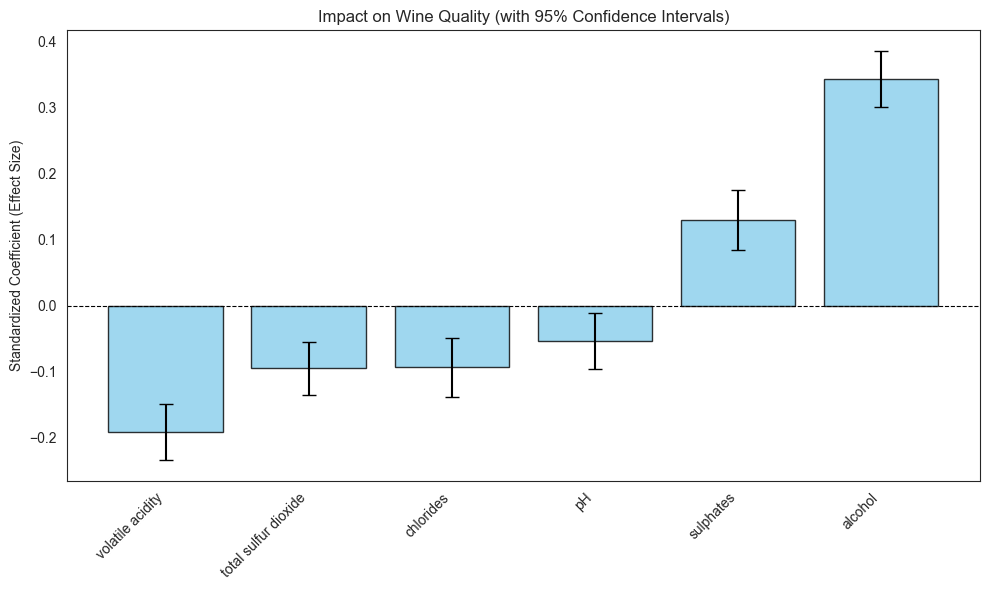

In [27]:
results = []
for feature_name in model.params.index:
    if feature_name == "const":
        continue

    coef = model.params[feature_name]
    ci_low = model.conf_int().loc[feature_name][0]
    ci_high = model.conf_int().loc[feature_name][1]

    results.append(
        {"pair": feature_name, "coef": coef, "ci_95_low": ci_low, "ci_95_high": ci_high}
    )

df = pd.DataFrame(results)

df = df.sort_values(by="coef", ascending=True)

x = range(len(df))

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    df["coef"],
    yerr=[df["coef"] - df["ci_95_low"], df["ci_95_high"] - df["coef"]],
    capsize=5,
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

plt.xticks(x, df["pair"], rotation=45, ha="right")

# Nulllinie und Labels
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel("Standardized Coefficient (Effect Size)")
plt.title("Impact on Wine Quality (with 95% Confidence Intervals)")
plt.tight_layout()
plt.show()

We see that for all CI 0 is not included which means the effect is statistically significant.

#### Interpretation

**R-squared (~0.38):**

The model explains about 38% of the variance in perceived wine quality. The model reduced the error by 38% compared to just taking the average. This indicates a moderate fit.

**Coefficients (Weights and bias):**

Looking at the p-values, we can identify the **most significant drivers of quality** (p < 0.05 and high coef):
- Alcohol: Strong positive coefficient - ~0.35 and 95% CI: [0.3, 0.385]. Higher alcohol content is associated with better quality ratings.
- Volatile Acidity: Strong negative coefficient - ~-0.19 and 95% CI: [-0.234, -0.149]. Higher levels of acetic acid significantly reduce perceived quality.
- Sulphates: Positive coefficient - ~0.13 and 95% CI: [0.085, 0.175]. Higher sulphate levels correlate with better perceived quality.
- Chlorides: Negative coefficient ~-0.09 and 95% CI: [-0.139, -0.048]. Salty taste negatively impacts quality score.

Our constant (bias) is ~5.65.

Alcohol has the largest positive impact and Volatile Acidity the largest negative one; you can see that in the plot above as well.
This also supports what we saw for the tendencies in the correlations section.

## Results

**Nullhypothesis 1:** The pH-value has NO impact on perceived wine quality.

**Alternative Hypothesis 1:** High pH-value has a NEGATIVE impact on perceived wine quality.

With a p value of 0.014 < 0.05 the pH value has a statistically significant impact on the quality score and the coef = -0.0537, which stands for a negative impact 

-> We reject the Nullhypothesis and conclude the Alternative Hypothesis

**Nullhypothesis 2:** The Fixed acidity has NO impact on perceived wine quality.

**Alternative Hypothesis 2:** Fixed acidity of wine has a NEGATIVE impact on perceived wine quality. 

The variable fixed acidity was removed from the final model due to high Multicollinearity (VIF > 7), meaning its effect was chemically redundant with other variables like pH and Density. Additionally, the initial correlation analysis showed a weak positive correlation (~0.12), which contradicts the hypothesis of a negative impact.

-> We fail to reject the Nullhypothesis. We cannot confirm a significant negative impact on quality.

**Nullhypothesis 3:** The alcohol content has NO impact on perceived wine quality.

**Hypothsesisn 3:** Higher alcohol content has a POSITIVE impact on perceived wine quality. 

p value: 0.00 < 0.05 and coef = 0.35, as seen been before. Alcohol has the largest positive impact.

-> We reject the Nullhypothesis and conclude the Alternative Hypothesis

## Sampling on Test data

Inspect how the model performs on the hold out dataset.

First we look at how the model performs on the whole test set.

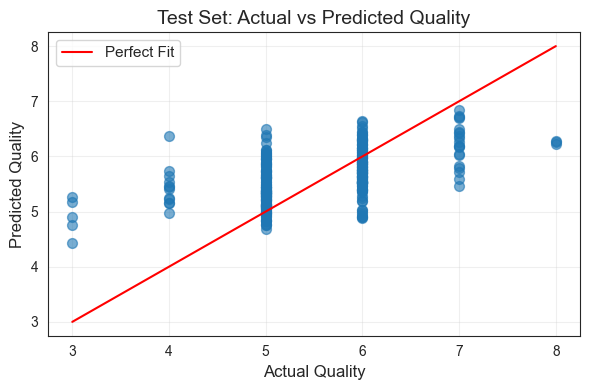

In [28]:
y_test_pred = model.predict(X_test_sm)
plot_regression(y_test, y_test_pred, "Test")

We can also take single random samples and obseeve the models capabilities.

In [29]:
sample = X_test_sm.sample(n=1)
sample

,const,volatile acidity,alcohol,sulphates,pH,chlorides,total sulfur dioxide
1124,1.0,0.772395,-0.26719,-0.027673,-0.237623,0.07895,1.169956


In [30]:
y = y_test[sample.index.item()]
y_sample = model.predict(sample)
print(f"sample prediction: {y_sample.item():.2f} vs. actual quality: {y}")

sample prediction: 5.30 vs. actual quality: 5


## Conclusion

We successfully built a linear regression model to predict wine quality based on physicochemical properties. While no single chemical feature explains wine quality on its own, the regression model shows that alcohol content and volatile acidity are the strongest and most statistically robust predictors of perceived wine quality.

### Suggestions for how the analysis could be improved

Since wine quality is subjective and likely depends on complex, non-linear interactions between chemical components, a simple linear regression cannot capture the full picture super accurately - e.g. constant ~5.6. We could use a more complex - non linear model - e.g. a Neural Net, Polynomial Regression ... to model the relationship more accurately.